In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, f1_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

BASE_PATH = "/content/drive/MyDrive/datasets"

print("BASE_PATH exists:", os.path.exists(BASE_PATH))
print("Files in folder:")
print(os.listdir(BASE_PATH))

BASE_PATH exists: True
Files in folder:
['CPIAUCSL.csv', 'GDPC1.csv', 'DFF_interest_rate.csv', 'data_gpr_daily_recent.csv', 'NASDAQCOM.csv', 'nasdaq_multivariate.csv']


In [4]:
import pandas as pd

nasdaq = pd.read_csv(f"{BASE_PATH}/NASDAQCOM.csv")
cpi = pd.read_csv(f"{BASE_PATH}/CPIAUCSL.csv")
gdp = pd.read_csv(f"{BASE_PATH}/GDPC1.csv")
rate = pd.read_csv(f"{BASE_PATH}/DFF_interest_rate.csv")
gpr = pd.read_csv(f"{BASE_PATH}/data_gpr_daily_recent.csv")

In [5]:
# Cell 5
print("NASDAQ columns:", nasdaq.columns.tolist())
print("CPI columns:", cpi.columns.tolist())
print("GDP columns:", gdp.columns.tolist())
print("Rate columns:", rate.columns.tolist())
print("GPR columns:", gpr.columns.tolist())

NASDAQ columns: ['observation_date', 'NASDAQCOM']
CPI columns: ['observation_date', 'CPIAUCSL']
GDP columns: ['observation_date', 'GDPC1']
Rate columns: ['observation_date', 'DFF']
GPR columns: ['DAY', 'N10D', 'GPRD', 'GPRD_ACT', 'GPRD_THREAT', 'date', 'GPRD_MA30', 'GPRD_MA7', 'event', 'var_name', 'var_label']


In [6]:
# Cell 6

nasdaq.rename(columns={"observation_date": "date"}, inplace=True)
cpi.rename(columns={"observation_date": "date"}, inplace=True)
gdp.rename(columns={"observation_date": "date"}, inplace=True)
rate.rename(columns={"observation_date": "date"}, inplace=True)

nasdaq = nasdaq.rename(columns={"NASDAQCOM": "nasdaq"})
gdp = gdp.rename(columns={"GDPC1": "gdp"})
cpi = cpi.rename(columns={"CPIAUCSL": "cpi"})
rate = rate.rename(columns={"DFF": "interest_rate"})
gpr = gpr.rename(columns={"GPRD_MA7": "gpr"})

nasdaq = nasdaq[["date", "nasdaq"]]
cpi = cpi[["date", "cpi"]]
gdp = gdp[["date", "gdp"]]
rate = rate[["date", "interest_rate"]]
gpr = gpr[["date", "gpr"]]

nasdaq["date"] = pd.to_datetime(nasdaq["date"])
cpi["date"] = pd.to_datetime(cpi["date"])
gdp["date"] = pd.to_datetime(gdp["date"])
rate["date"] = pd.to_datetime(rate["date"])
gpr["date"] = pd.to_datetime(gpr["date"])


print("After rename:")
print("NASDAQ:", nasdaq.columns.tolist())
print("CPI:", cpi.columns.tolist())
print("GDP:", gdp.columns.tolist())
print("Rate:", rate.columns.tolist())
print("GPR:", gpr.columns.tolist())

After rename:
NASDAQ: ['date', 'nasdaq']
CPI: ['date', 'cpi']
GDP: ['date', 'gdp']
Rate: ['date', 'interest_rate']
GPR: ['date', 'gpr']


In [7]:
_df = nasdaq.merge(cpi, on="date", how="inner")
_df = _df.merge(gdp, on="date", how="inner")
_df = _df.merge(rate, on="date", how="inner")
_df = _df.merge(gpr, on="date", how="inner")

_df = _df.sort_values("date").reset_index(drop=True)

print(_df.head())
print(_df.tail())
print("Shape:", _df.shape)

        date  nasdaq    cpi       gdp  interest_rate     gpr
0 1985-01-01     NaN  105.7  8400.820           8.74  230.04
1 1985-04-01  280.32  107.0  8474.787           8.83  109.52
2 1985-07-01  296.48  107.7  8604.220           8.12  200.81
3 1985-10-01  281.77  108.5  8668.188           8.26  129.54
4 1986-01-01     NaN  109.9  8749.127          13.46  199.80
          date    nasdaq      cpi        gdp  interest_rate     gpr
114 2024-10-01  17910.36  315.631  23586.542           4.83  145.13
115 2025-01-01       NaN  318.961  23548.210           4.33  110.21
116 2025-04-01  17449.89  320.302  23770.976           4.33  128.94
117 2025-07-01  20202.89  322.169  24026.834           4.33  190.41
118 2025-10-01  22755.16      NaN  24065.956           4.09  121.91
Shape: (119, 6)


In [8]:
df = _df.copy()

# base return
returns = df["nasdaq"].pct_change() * 100  # Convert to percentage

# dynamic external
df["rate_change"] = df["interest_rate"].diff()

# target (next day) return
target = returns.shift(-1)

# Multi-task targets
df["target_magnitude"] = target.abs()  # Absolute value of return
df["target_direction"] = (target > 0).astype(float)  # 1.0 if up, 0.0 if down/flat

# Input features: decompose return into magnitude and direction
df["return_magnitude"] = returns.abs()  # Absolute value
df["return_direction"] = (returns > 0).astype(float)  # 1.0 if up, 0.0 if down

df = df.dropna().reset_index(drop=True)


SAMPLE_INTERVAL = 1
df = df.iloc[::SAMPLE_INTERVAL].reset_index(drop=True)

seq_feature_cols = [
    "return_magnitude",
    "return_direction",
    "gpr",
    "rate_change",
]

print(df.head())
print(df.shape)

        date  nasdaq    cpi       gdp  interest_rate     gpr  rate_change  \
0 1985-07-01  296.48  107.7  8604.220           8.12  200.81        -0.71   
1 1985-10-01  281.77  108.5  8668.188           8.26  129.54         0.14   
2 1986-04-01  374.15  108.7  8788.524           7.49  146.06        -5.97   
3 1986-07-01  407.61  109.5  8872.601           6.97  101.50        -0.52   
4 1986-10-01  352.34  110.2  8920.193           5.99  117.90        -0.98   

   target_magnitude  target_direction  return_magnitude  return_direction  
0          4.961549               0.0          5.764840               1.0  
1          0.000000               0.0          4.961549               0.0  
2          8.942937               1.0         32.785605               1.0  
3         13.559530               0.0          8.942937               1.0  
4          0.000000               0.0         13.559530               0.0  
(85, 11)


/tmp/ipykernel_3485/3113399010.py:4: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df["nasdaq"].pct_change() * 100  # Convert to percentage


In [9]:
TRAIN_RATIO = 0.6
VAL_RATIO = 0.7
TEST_RATIO = 0.8
WINDOW_SIZE = 45

n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * VAL_RATIO)
test_end = int(n * TEST_RATIO)

train_df = df.iloc[:train_end].reset_index(drop=True)
val_df = df.iloc[train_end:val_end].reset_index(drop=True)
test_df = df.iloc[val_end:test_end].reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 51
Val size: 8
Test size: 9


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df[seq_feature_cols])
val_scaled = scaler.transform(val_df[seq_feature_cols])
test_scaled = scaler.transform(test_df[seq_feature_cols])

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[seq_feature_cols] = train_scaled
val_df_scaled[seq_feature_cols] = val_scaled
test_df_scaled[seq_feature_cols] = test_scaled

train_df_scaled.head(4)

,date,nasdaq,cpi,gdp,interest_rate,gpr,rate_change,target_magnitude,target_direction,return_magnitude,return_direction
0,1985-07-01,296.48,107.7,8604.220,8.12,0.765301,-0.272774,4.961549,0.0,-0.616514,0.738549
1,1985-10-01,281.77,108.5,8668.188,8.26,0.073100,0.257009,0.000000,0.0,-0.677958,-1.354006
2,1986-04-01,374.15,108.7,8788.524,7.49,0.233548,-3.551198,8.942937,1.0,1.450311,0.738549
3,1986-07-01,407.61,109.5,8872.601,6.97,-0.199235,-0.154352,13.559530,0.0,-0.373421,0.738549


In [11]:
class MultiFeatureSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, window_size=60):
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.window_size = window_size

        self.X = self.df[feature_cols].values.astype(np.float32)
        self.y_mag = self.df["target_magnitude"].values.astype(np.float32)
        self.y_dir = self.df["target_direction"].values.astype(np.float32)

    def __len__(self):
        return len(self.df) - self.window_size

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.window_size]
        y_mag = self.y_mag[idx + self.window_size - 1]
        y_dir = self.y_dir[idx + self.window_size - 1]

        x_seq = torch.tensor(x_seq)
        y_mag = torch.tensor(y_mag)
        y_dir = torch.tensor(y_dir)

        return x_seq, (y_mag, y_dir)

In [12]:
BATCH_SIZE = 128

train_dataset = MultiFeatureSequenceDataset(train_df_scaled, seq_feature_cols, WINDOW_SIZE)
val_dataset = MultiFeatureSequenceDataset(val_df_scaled, seq_feature_cols, WINDOW_SIZE)
test_dataset = MultiFeatureSequenceDataset(test_df_scaled, seq_feature_cols, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train dataset:", len(train_dataset))
print("Val dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

print("train dataset:")
print(train_df_scaled)

Train dataset: 6


ValueError: __len__() should return >= 0

In [ ]:
class FeatureAttention(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Tanh(),
            nn.Linear(input_size, input_size)
        )

    def forward(self, x):
        # x: (batch, window, input_size)
        scores = self.attn(x)
        weights = torch.softmax(scores, dim=-1)
        x_weighted = x * weights
        return x_weighted, weights


class TimeAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, lstm_out):
        # lstm_out: (batch, window, hidden)
        scores = self.attn(lstm_out).squeeze(-1)      # (batch, window)
        weights = torch.softmax(scores, dim=1)        # (batch, window)
        context = torch.sum(lstm_out * weights.unsqueeze(-1), dim=1)
        return context, weights


class FinalStage1Model(nn.Module):
    def __init__(self, input_size, hidden_size=256, num_layers=2, dropout=0.2, fc_hidden=64):
        super().__init__()

        self.feature_attention = FeatureAttention(input_size)

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )

        self.time_attention = TimeAttention(hidden_size)  # *2 for bidirectional

        # Magnitude head: predicts absolute value (continuous)
        self.magnitude_head = nn.Sequential(
            nn.Linear(hidden_size, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, 1),
            nn.ReLU()  # Ensure non-negative magnitude
        )

        # Direction head: predicts probability (0-1)
        self.direction_head = nn.Sequential(
            nn.Linear(hidden_size, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, 1),
            nn.Sigmoid()  # Output probability
        )

    def forward(self, x, return_attention=False):
        x_weighted, feature_weights = self.feature_attention(x)
        lstm_out, _ = self.lstm(x_weighted)
        context, time_weights = self.time_attention(lstm_out)

        mag_pred = self.magnitude_head(context).squeeze(-1)
        dir_pred = self.direction_head(context).squeeze(-1)

        if return_attention:
            return mag_pred, dir_pred, feature_weights, time_weights
        return mag_pred, dir_pred

: 

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = FinalStage1Model(
    input_size=len(seq_feature_cols),
    hidden_size=256,
    num_layers=2,
    dropout=0.3,
    fc_hidden=64
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)



scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=30
)

Using device: cuda


: 

In [ ]:
mse_loss_fn = nn.MSELoss()
bce_loss_fn = nn.BCELoss()

def multi_task_loss(mag_pred, dir_pred, mag_target, dir_target, alpha=0.3, beta=0.7):
    """
    Multi-task loss combining magnitude and direction prediction.
    alpha: weight for magnitude loss
    beta: weight for direction loss
    """
    # Magnitude loss: MSE on absolute values
    mag_loss = mse_loss_fn(mag_pred, mag_target)
    
    # Direction loss: Binary cross entropy on probabilities
    dir_loss = bce_loss_fn(dir_pred, dir_target)

    return alpha * mag_loss + beta * dir_loss

: 

In [ ]:
EARLY_STOP_PATIENCE = 100

best_val_loss = float("inf")
best_state = None
no_improve = 0

train_losses = []
val_losses = []

epoch = 0

while True:
    model.train()
    running_train_loss = 0.0

    for x_seq, (y_mag, y_dir) in train_loader:
        x_seq = x_seq.to(device)
        y_mag = y_mag.to(device)
        y_dir = y_dir.to(device)

        mag_pred, dir_pred = model(x_seq)
        loss = multi_task_loss(mag_pred, dir_pred, y_mag, y_dir)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    scheduler.step(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for x_seq, (y_mag, y_dir) in val_loader:
            x_seq = x_seq.to(device)
            y_mag = y_mag.to(device)
            y_dir = y_dir.to(device)

            mag_pred, dir_pred = model(x_seq)
            loss = multi_task_loss(mag_pred, dir_pred, y_mag, y_dir)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.6f}, Val Loss = {avg_val_loss:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= EARLY_STOP_PATIENCE:
        print("Early stopping triggered.")
        break

    epoch += 1

model.load_state_dict(best_state)

Epoch 1: Train Loss = 0.741023, Val Loss = 0.624871
Epoch 2: Train Loss = 0.727187, Val Loss = 0.623370
Epoch 3: Train Loss = 0.724239, Val Loss = 0.631861
Epoch 4: Train Loss = 0.702902, Val Loss = 0.625853
Epoch 5: Train Loss = 0.684253, Val Loss = 0.620400
Epoch 6: Train Loss = 0.686740, Val Loss = 0.617241
Epoch 7: Train Loss = 0.686921, Val Loss = 0.617746
Epoch 8: Train Loss = 0.678801, Val Loss = 0.617070
Epoch 9: Train Loss = 0.679969, Val Loss = 0.616870
Epoch 10: Train Loss = 0.680574, Val Loss = 0.614546
Epoch 11: Train Loss = 0.680067, Val Loss = 0.614386
Epoch 12: Train Loss = 0.677088, Val Loss = 0.614558
Epoch 13: Train Loss = 0.675463, Val Loss = 0.614355
Epoch 14: Train Loss = 0.679198, Val Loss = 0.613454
Epoch 15: Train Loss = 0.673274, Val Loss = 0.615053
Epoch 16: Train Loss = 0.675089, Val Loss = 0.614027
Epoch 17: Train Loss = 0.675469, Val Loss = 0.617828
Epoch 18: Train Loss = 0.674765, Val Loss = 0.618074
Epoch 19: Train Loss = 0.672833, Val Loss = 0.612353
Ep

<All keys matched successfully>

: 

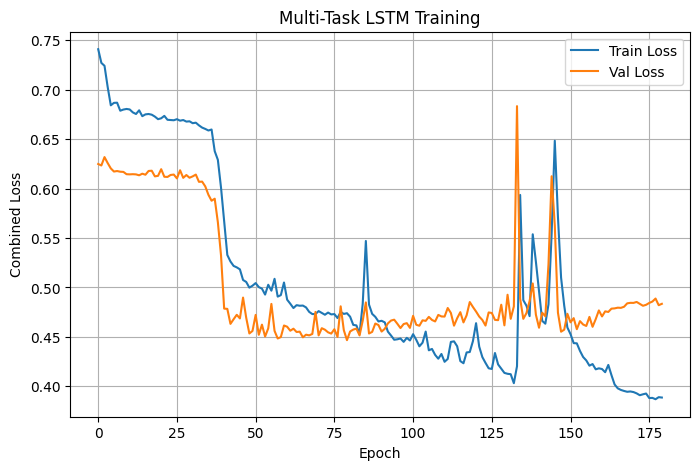

===== TEST RESULTS =====

--- MAGNITUDE HEAD ---
MSE: 0.22706127
MAE: 0.33096495

--- DIRECTION HEAD ---
Accuracy (0.5 threshold): 0.68191268
F1 Score: 0.75880189
AUC-ROC: 0.74633046
baseline direction accuracy (majority class): 0.56340957


: 

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Combined Loss")
plt.title("Multi-Task LSTM Training")
plt.legend()
plt.grid(True)
plt.show()

from sklearn.metrics import roc_auc_score

model.eval()

all_mag_preds = []
all_dir_preds = []
all_mag_targets = []
all_dir_targets = []

with torch.no_grad():
    for x_seq, (y_mag, y_dir) in test_loader:
        x_seq = x_seq.to(device)
        mag_pred, dir_pred = model(x_seq)
        
        all_mag_preds.append(mag_pred.cpu().numpy())
        all_dir_preds.append(dir_pred.cpu().numpy())
        all_mag_targets.append(y_mag.numpy())
        all_dir_targets.append(y_dir.numpy())

mag_preds = np.concatenate(all_mag_preds)
dir_preds = np.concatenate(all_dir_preds)
mag_targets = np.concatenate(all_mag_targets)
dir_targets = np.concatenate(all_dir_targets)

# Magnitude metrics
mag_mse = np.mean((mag_preds - mag_targets) ** 2)
mag_mae = mean_absolute_error(mag_targets, mag_preds)

# Direction metrics
dir_pred_binary = (dir_preds > 0.5).astype(int)
dir_accuracy = np.mean(dir_pred_binary == dir_targets)
dir_f1 = f1_score(dir_targets, dir_pred_binary)

# AUC-ROC for direction (using probabilities directly)
dir_auc = roc_auc_score(dir_targets, dir_preds)

print("===== TEST RESULTS =====")
print(f"\n--- MAGNITUDE HEAD ---")
print(f"MSE: {mag_mse:.8f}")
print(f"MAE: {mag_mae:.8f}")
print(f"\n--- DIRECTION HEAD ---")
print(f"Accuracy (0.5 threshold): {dir_accuracy:.8f}")
print(f"F1 Score: {dir_f1:.8f}")
print(f"AUC-ROC: {dir_auc:.8f}")

print("baseline direction accuracy (majority class):", np.mean(dir_targets))

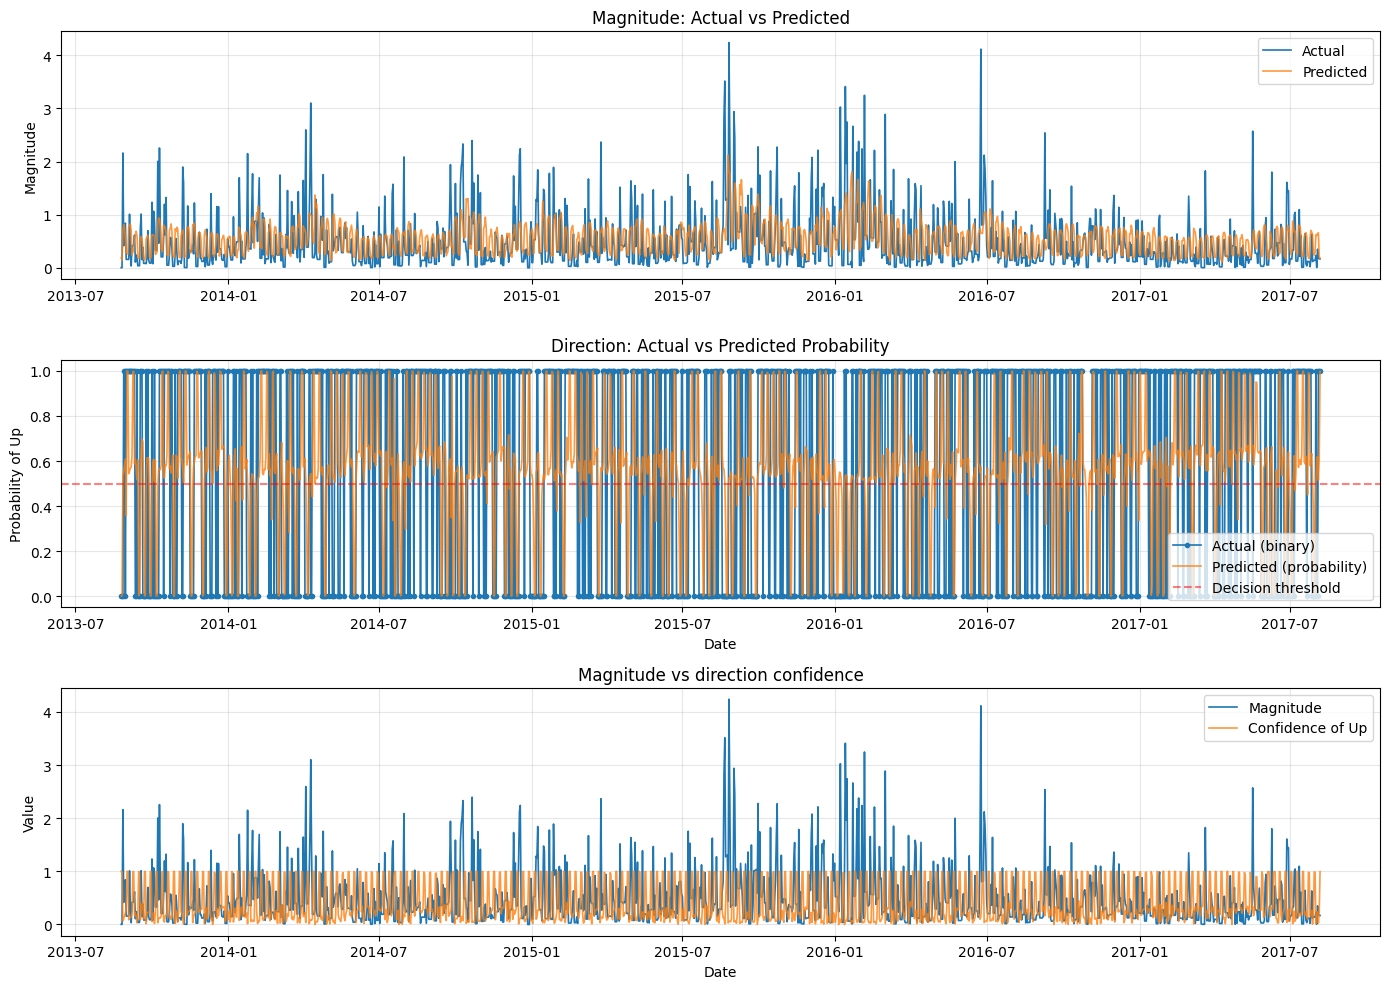

: 

In [ ]:
test_dates = test_df["date"].values[WINDOW_SIZE:WINDOW_SIZE + len(mag_preds)]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Magnitude predictions
axes[0].plot(test_dates, mag_targets, label="Actual", linewidth=1.2)
axes[0].plot(test_dates, mag_preds, label="Predicted", linewidth=1.2, alpha=0.8)
axes[0].set_title("Magnitude: Actual vs Predicted")
axes[0].set_ylabel("Magnitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Direction predictions (as probabilities)
axes[1].plot(test_dates, dir_targets, label="Actual (binary)", linewidth=1.2, marker='.')
axes[1].plot(test_dates, dir_preds, label="Predicted (probability)", linewidth=1.2, alpha=0.8)
axes[1].axhline(0.5, color='r', linestyle='--', alpha=0.5, label='Decision threshold')
axes[1].set_title("Direction: Actual vs Predicted Probability")
axes[1].set_ylabel("Probability of Up")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(test_dates, mag_targets, label="Magnitude", linewidth=1.2)
axes[2].plot(test_dates, 2*abs(dir_preds - 0.5), label="Confidence of Up", linewidth=1.2, alpha=0.8)
axes[2].set_title("Magnitude vs direction confidence")
axes[2].set_ylabel("Value")
axes[2].set_xlabel("Date")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

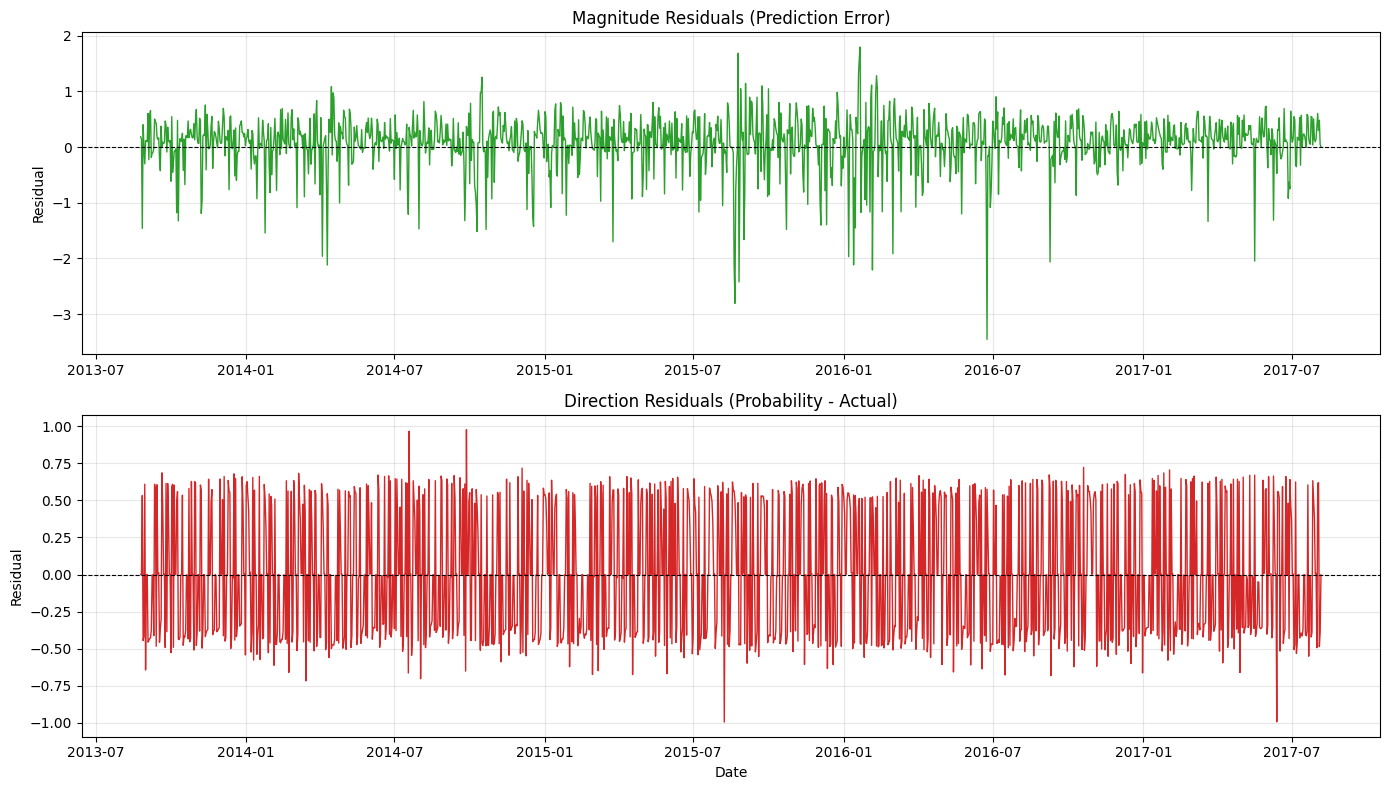

: 

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Magnitude residuals
mag_residuals = mag_preds - mag_targets
axes[0].plot(test_dates, mag_residuals, linewidth=1.0, color='C2')
axes[0].axhline(0, linestyle="--", color='black', linewidth=0.8)
axes[0].set_title("Magnitude Residuals (Prediction Error)")
axes[0].set_ylabel("Residual")
axes[0].grid(True, alpha=0.3)

# Direction residuals
dir_residuals = dir_preds - dir_targets
axes[1].plot(test_dates, dir_residuals, linewidth=1.0, color='C3')
axes[1].axhline(0, linestyle="--", color='black', linewidth=0.8)
axes[1].set_title("Direction Residuals (Probability - Actual)")
axes[1].set_ylabel("Residual")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Bin 0.50-0.53: Accuracy=0.487, Count=150, avg confidence=0.513, magnitude=0.452
Bin 0.53-0.55: Accuracy=0.594, Count=175, avg confidence=0.537, magnitude=0.518
Bin 0.55-0.57: Accuracy=0.550, Count=160, avg confidence=0.562, magnitude=0.446
Bin 0.57-0.60: Accuracy=0.615, Count=135, avg confidence=0.586, magnitude=0.588
Bin 0.60-0.62: Accuracy=0.566, Count=159, avg confidence=0.614, magnitude=0.444
Bin 0.62-0.65: Accuracy=0.544, Count=147, avg confidence=0.637, magnitude=0.467
Bin 0.65-0.68: Accuracy=0.500, Count=72, avg confidence=0.661, magnitude=0.412
Bin 0.68-0.70: Accuracy=0.625, Count=16, avg confidence=0.684, magnitude=0.197
Bin 0.70-0.72: Accuracy=0.545, Count=11, avg confidence=0.712, magnitude=0.350
Bin 0.98-1.00: Accuracy=0.993, Count=409, avg confidence=0.997, magnitude=0.437


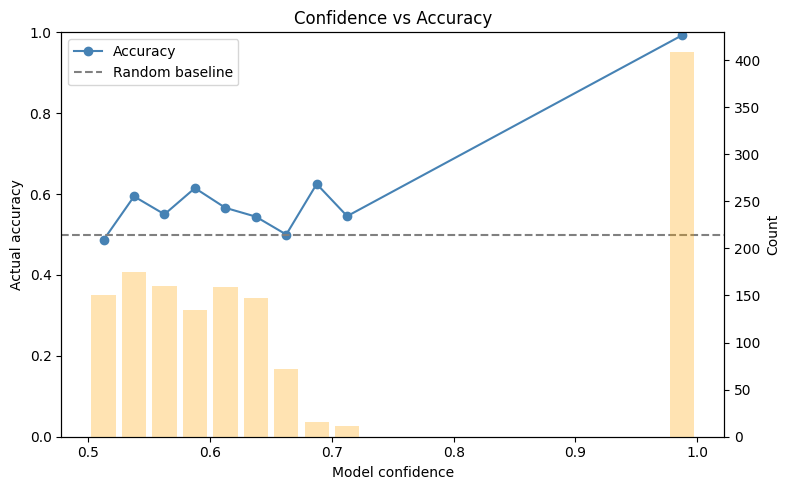

: 

In [ ]:
def reliability_plot(y_true, y_prob, magnitude, n_bins=20):
    
    # confidence of predicting up (prob > 0.5)
    mask_up = y_prob >= 0.5
    conf_up = y_prob[mask_up]
    acc_up = y_true[mask_up]
    
    # confidence of predicting down (prob < 0.5)
    mask_down = y_prob < 0.5
    conf_down = 1 - y_prob[mask_down]
    acc_down = 1 - y_true[mask_down]
    
    confidence = np.concatenate([conf_up, conf_down])
    correct = np.concatenate([acc_up, acc_down])
    
    bins = np.linspace(0.5, 1.0, n_bins + 1)
    bin_centers, accuracies, counts = [], [], []
    
    for i in range(n_bins):
        mask = (confidence >= bins[i]) & (confidence < bins[i+1])
        if mask.sum() < 10:
            continue
        bin_centers.append((bins[i] + bins[i+1]) / 2)
        accuracies.append(correct[mask].mean())
        counts.append(mask.sum())
        print(f"Bin {bins[i]:.2f}-{bins[i+1]:.2f}: Accuracy={accuracies[-1]:.3f}, Count={counts[-1]}, avg confidence={confidence[mask].mean():.3f}, magnitude={magnitude[mask].mean():.3f}")
    
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(bin_centers, accuracies, marker='o', color='steelblue', label='Accuracy')
    ax1.axhline(0.5, linestyle='--', color='gray', label='Random baseline')
    ax1.set_xlabel('Model confidence')
    ax1.set_ylabel('Actual accuracy')
    ax1.set_ylim(0, 1)
    
    ax2 = ax1.twinx()
    ax2.bar(bin_centers, counts, width=0.02, alpha=0.3, color='orange', label='Sample count')
    ax2.set_ylabel('Count')
    
    ax1.legend(loc='upper left')
    plt.title('Confidence vs Accuracy')
    plt.tight_layout()
    plt.show()

reliability_plot(dir_targets, dir_preds, mag_targets, n_bins=20)

In [ ]:

print(f"ROC AUC score for direction: {roc_auc_score(dir_targets, dir_preds)}")

f1_raise = f1_score(dir_targets, (dir_preds > 0.5).astype(int), pos_label=1)
f1_fall = f1_score(dir_targets, (dir_preds > 0.5).astype(int), pos_label=0)
print(f"F1 score for raising: {f1_raise}")
print(f"F1 score for falling: {f1_fall}")
print(np.mean(dir_targets == 1))
print(np.mean(dir_targets == 0))
print(f"Mean absolute error for magnitude: {mean_absolute_error(mag_targets, mag_preds)}")
print(f"Mean absolute error for direction: {mean_absolute_error(dir_targets, dir_preds)}")
print(f"total samples: {len(dir_targets)}")


print(f"Confidence for raising: {np.mean(dir_preds[dir_targets == 1])}")
print(f"Confidence for falling: {np.mean(dir_preds[dir_targets == 0])}")

ROC AUC score for direction: 0.746330463304633
F1 score for raising: 0.7588018917498687
F1 score for falling: 0.5330620549338759
0.5634095634095634
0.4365904365904366
Mean absolute error for magnitude: 0.33096495270729065
Mean absolute error for direction: 0.35211485624313354
total samples: 1443
Confidence for raising: 0.683625340461731
Confidence for falling: 0.39823681116104126


: 